In [2]:
from __future__ import annotations

import jax.numpy as jnp
import numpy as np
import dynamiqs as dq

from parameters import DeviceParameters, PulseParameters
from hamiltonian import operators

In [3]:
from parameters import load_json

# Load the JSON
device, pulse, simulation = load_json("device_parameter.json")

# -------------------------------
# Print the loaded objects
# -------------------------------

print("===== Device =====")
print(device)
print()

print("===== Pulse =====")
print(pulse)
print()

print("===== Simulation =====")
print(simulation)
print()

# -------------------------------
# Print individual pulse fields
# -------------------------------

print("omega_d   :", pulse.omega_d)
print("epsilon1  :", pulse.epsilon1)
print("epsilon2  :", pulse.epsilon2)
print("t_switch  :", pulse.t_switch)
print("t_off     :", pulse.t_off)
print()

# -------------------------------
# Test the modulation manually
# -------------------------------

import jax.numpy as jnp

def modulation(t):
    amp = jnp.where(
        t < pulse.t_switch,
        pulse.epsilon1,
        jnp.where(
            t < pulse.t_off,
            pulse.epsilon2,
            0.0,
        ),
    )
    return 0.5 * amp

print("===== Modulation values =====")

for t in [0, 50, 99, 100, 150, 299, 300, 301, 500]:
    print(f"t = {t:3d} ns   ->   {float(modulation(t))}")

===== Device =====
DeviceParameters(omega_levels=array([  0.        ,   1.9419542 ,  21.25223419,  33.317823  ,
        50.53448558,  68.13257833,  86.46366135, 104.79519517,
       122.70291326, 139.70606541, 155.35803526, 169.41756814,
       182.19430127, 194.52899199, 207.14971474, 220.27305353,
       233.85239491, 247.83371454, 262.18338959, 276.86830534]), n_matrix_real=array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.

In [4]:
print(pulse.epsilon1/(2*np.pi) * 1e3)
print(pulse.epsilon2/(2*np.pi) * 1e3)

45.0
45.0


In [5]:
print(device.g/(2*np.pi))

0.09


In [6]:
import numpy as np

epsilon = 0.251327
kappa = 0.031415926535897934

print((epsilon / kappa) ** 2)

63.99979002403392


In [7]:
ops = operators(device, pulse)

test = ops["drive_op"] - (-1j)*(ops["a"] - ops["a"].dag())

print(np.max(np.abs(np.asarray(test))))

/mnt/d/GPU_fluxonium/hamiltonian.py:57: UserWarning: A sparse qarray has been converted to dense layout due to element-wise addition with a dense qarray.
  "h_static": h_resonator + h_fluxonium + params.g * drive_op @ n,


0.0


In [8]:
import dynamiqs as dq
print(dq.__version__)

0.3.4


In [9]:
ops = operators(device, pulse)
print(ops["drive_op"])

QArray: shape=(1300, 1300), dims=(20, 65), dtype=complex64, layout=dia, ndiags=2
[[  ⋅           0.-1.j          ⋅           ...   ⋅   
    ⋅             ⋅          ]
 [0.+1.j          ⋅           0.-1.4142135j ...   ⋅   
    ⋅             ⋅          ]
 [  ⋅           0.+1.4142135j   ⋅           ...   ⋅   
    ⋅             ⋅          ]
 ...
 [  ⋅             ⋅             ⋅           ...   ⋅   
  0.-7.937254j    ⋅          ]
 [  ⋅             ⋅             ⋅           ... 0.+7.937254j
    ⋅           0.-8.j       ]
 [  ⋅             ⋅             ⋅           ...   ⋅   
  0.+8.j          ⋅          ]]


In [10]:
ops = operators(device, pulse)

print("a:")
print(ops["a"])

print("drive_op:")
print(ops["drive_op"])

print("a + adag:")
print(ops["a"] + ops["a"].dag())

a:
QArray: shape=(1300, 1300), dims=(20, 65), dtype=complex64, layout=dia, ndiags=1
[[      ⋅       1.       +0.j       ⋅       ...       ⋅      
        ⋅             ⋅      ]
 [      ⋅             ⋅       1.4142135+0.j ...       ⋅      
        ⋅             ⋅      ]
 [      ⋅             ⋅             ⋅       ...       ⋅      
        ⋅             ⋅      ]
 ...
 [      ⋅             ⋅             ⋅       ...       ⋅      
  7.937254 +0.j       ⋅      ]
 [      ⋅             ⋅             ⋅       ...       ⋅      
        ⋅       8.       +0.j]
 [      ⋅             ⋅             ⋅       ...       ⋅      
        ⋅             ⋅      ]]
drive_op:
QArray: shape=(1300, 1300), dims=(20, 65), dtype=complex64, layout=dia, ndiags=2
[[  ⋅           0.-1.j          ⋅           ...   ⋅   
    ⋅             ⋅          ]
 [0.+1.j          ⋅           0.-1.4142135j ...   ⋅   
    ⋅             ⋅          ]
 [  ⋅           0.+1.4142135j   ⋅           ...   ⋅   
    ⋅             ⋅          ]
 ..

In [11]:
print(((np.pi * 2)/pulse.omega_d) * 10000)

1396.180051379426


In [12]:
t = 0
times = [0.0]
for x in range(0,500):
    t = t + (np.pi * 2)/pulse.omega_d
    times.append(t)

In [13]:
print(times)

[0.0, 0.1396180051379426, 0.2792360102758852, 0.4188540154138278, 0.5584720205517704, 0.6980900256897129, 0.8377080308276554, 0.977326035965598, 1.1169440411035405, 1.256562046241483, 1.3961800513794256, 1.5357980565173681, 1.6754160616553107, 1.8150340667932532, 1.9546520719311957, 2.0942700770691385, 2.233888082207081, 2.3735060873450236, 2.513124092482966, 2.6527420976209086, 2.792360102758851, 2.9319781078967937, 3.0715961130347362, 3.2112141181726788, 3.3508321233106213, 3.490450128448564, 3.6300681335865064, 3.769686138724449, 3.9093041438623914, 4.048922149000334, 4.188540154138277, 4.32815815927622, 4.467776164414163, 4.607394169552106, 4.747012174690049, 4.886630179827992, 5.026248184965935, 5.165866190103878, 5.305484195241821, 5.445102200379764, 5.584720205517707, 5.72433821065565, 5.863956215793593, 6.003574220931536, 6.143192226069479, 6.282810231207422, 6.422428236345365, 6.562046241483308, 6.701664246621251, 6.841282251759194, 6.980900256897137, 7.1205182620350795, 7.260

In [14]:
print(f"{2*np.pi:.3f}")

6.283


In [15]:
def wrap_angle_closed(theta):
    x = theta % (2*6.283)
    return 2*np.pi if np.isclose(x, 0.0) and theta != 0 else x

In [16]:
import jax.numpy as jnp

def wrap_angle(theta):
    return jnp.mod(theta, 2 * np.pi)

In [17]:
t_mod = jnp.mod(t, (2*np.pi))
print(t_mod)

0.69396544


In [18]:
def periodic(limit: float):
    ip = limit
    x = limit
    for i in range(0,100):
        if x >= 0:
            ip = x
            x = (limit - ((np.pi * 2)))
            #print(x)
            
    return np.abs(ip)

In [19]:
#times = np.linspace(0, 600, 1000)
for t in times:
    p = wrap_angle( pulse.omega_d * t)

    x = np.exp((-1j) * p)

    print( "-----",  f"{x:.3f}")


----- 1.000-0.000j
----- 1.000-0.000j
----- 1.000-0.000j
----- 1.000+0.000j
----- 1.000-0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000-0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000-0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000-0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000-0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000-0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000-0.000j
----- 1.000+0.000j
----- 1.000-0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000+0.000j
----- 1.000-

In [20]:
import numpy as np

A = np.array(ops["drive_op"])

print(np.max(np.abs(np.real(A))))
print(np.max(np.abs(np.imag(A))))

0.0
8.0


In [21]:
print(ops["a"])
print(ops["drive_op"])
print(-1j * (ops["a"] - ops["a"].dag()))
print(ops["a"] + ops["a"].dag())

QArray: shape=(1300, 1300), dims=(20, 65), dtype=complex64, layout=dia, ndiags=1
[[      ⋅       1.       +0.j       ⋅       ...       ⋅      
        ⋅             ⋅      ]
 [      ⋅             ⋅       1.4142135+0.j ...       ⋅      
        ⋅             ⋅      ]
 [      ⋅             ⋅             ⋅       ...       ⋅      
        ⋅             ⋅      ]
 ...
 [      ⋅             ⋅             ⋅       ...       ⋅      
  7.937254 +0.j       ⋅      ]
 [      ⋅             ⋅             ⋅       ...       ⋅      
        ⋅       8.       +0.j]
 [      ⋅             ⋅             ⋅       ...       ⋅      
        ⋅             ⋅      ]]
QArray: shape=(1300, 1300), dims=(20, 65), dtype=complex64, layout=dia, ndiags=2
[[  ⋅           0.-1.j          ⋅           ...   ⋅   
    ⋅             ⋅          ]
 [0.+1.j          ⋅           0.-1.4142135j ...   ⋅   
    ⋅             ⋅          ]
 [  ⋅           0.+1.4142135j   ⋅           ...   ⋅   
    ⋅             ⋅          ]
 ...
 [  ⋅      

In [22]:
import inspect
import dynamiqs as dq

print(inspect.signature(dq.mesolve))

(H: 'QArrayLike | TimeQArray', jump_ops: 'list[QArrayLike | TimeQArray]', rho0: 'QArrayLike', tsave: 'ArrayLike', *, exp_ops: 'list[QArrayLike] | None' = None, method: 'Method' = Tsit5(), gradient: 'Gradient | None' = None, options: 'Options' = Options()) -> 'MESolveResult'


In [23]:
import dynamiqs as dq

print(dir(dq))

['DSMESolveResult', 'DSSESolveResult', 'DenseQArray', 'FloquetResult', 'JSMESolveResult', 'JSSESolveResult', 'MEPropagatorResult', 'MESolveResult', 'Options', 'QArray', 'QArrayLike', 'SEPropagatorResult', 'SESolveResult', 'SparseDIAQArray', 'TimeQArray', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_checks', '_utils', 'asqarray', 'basis', 'basis_dm', 'bloch_coordinates', 'braket', 'cd_gate', 'clicktimes_sse_to_sme', 'cnot', 'coherent', 'coherent_dm', 'constant', 'cosm', 'create', 'dag', 'dense', 'dense_qarray', 'destroy', 'dia', 'displace', 'dissipator', 'dsmesolve', 'dssesolve', 'entropy_relative', 'entropy_vn', 'excited', 'excited_dm', 'expect', 'expm', 'eye', 'eye_like', 'fidelity', 'floquet', 'fock', 'fock_dm', 'general', 'global_settings', 'gradient', 'ground', 'ground_dm', 'hadamard', 'hc', 'helpers', 'hermitian_conjugate', 'integrators', 'isbra', 'isdm', 'isherm', 'isket', 'isop', 'isqarrayl

In [24]:
print(type(dq.mesolve))

<class 'function'>


In [25]:
help(dq.mesolve)

Help on function mesolve in module dynamiqs.integrators.apis.mesolve:

mesolve(H: 'QArrayLike | TimeQArray', jump_ops: 'list[QArrayLike | TimeQArray]', rho0: 'QArrayLike', tsave: 'ArrayLike', *, exp_ops: 'list[QArrayLike] | None' = None, method: 'Method' = Tsit5(), gradient: 'Gradient | None' = None, options: 'Options' = Options()) -> 'MESolveResult'
    Solve the Lindblad master equation.

    This function computes the evolution of the density matrix $\rho(t)$ at time $t$,
    starting from an initial state $\rho_0$, according to the Lindblad master
    equation (with $\hbar=1$ and where time is implicit(1))
    $$
        \frac{\dd\rho}{\dt} = -i[H, \rho]
        + \sum_{k=1}^N \left(
            L_k \rho L_k^\dag
            - \frac{1}{2} L_k^\dag L_k \rho
            - \frac{1}{2} \rho L_k^\dag L_k
        \right),
    $$
    where $H$ is the system's Hamiltonian and $\{L_k\}$ is a collection of jump
    operators.
    { .annotate }

    1. With explicit time dependence:
        -

In [26]:
from dynamiqs.method import Tsit5
import inspect

print(inspect.signature(Tsit5))

(rtol: 'float' = 1e-06, atol: 'float' = 1e-06, safety_factor: 'float' = 0.9, min_factor: 'float' = 0.2, max_factor: 'float' = 5.0, max_steps: 'int' = 100000)


In [27]:
from dynamiqs.method import Dopri8
import inspect
print(inspect.signature(Dopri8))

(rtol: 'float' = 1e-06, atol: 'float' = 1e-06, safety_factor: 'float' = 0.9, min_factor: 'float' = 0.2, max_factor: 'float' = 5.0, max_steps: 'int' = 100000)


In [28]:
ops = operators(device, pulse)

print(type(ops["h_static"]))
print(ops["h_static"])

<class 'dynamiqs.qarrays.dense_qarray.DenseQArray'>
QArray: shape=(1300, 1300), dims=(20, 65), dtype=complex64, layout=dense
[[ 0.0000000e+00+0.j -2.5565991e-32+0.j  0.0000000e+00+0.j ...
   0.0000000e+00+0.j  0.0000000e+00+0.j  0.0000000e+00+0.j]
 [ 2.5565991e-32+0.j  4.5003944e+01+0.j -3.6155770e-32+0.j ...
   0.0000000e+00+0.j  0.0000000e+00+0.j  0.0000000e+00+0.j]
 [ 0.0000000e+00+0.j  3.6155770e-32+0.j  9.0007881e+01+0.j ...
   0.0000000e+00+0.j  0.0000000e+00+0.j  0.0000000e+00+0.j]
 ...
 [ 0.0000000e+00+0.j  0.0000000e+00+0.j  0.0000000e+00+0.j ...
   3.0671128e+03+0.j  2.1988177e-30+0.j  0.0000000e+00+0.j]
 [ 0.0000000e+00+0.j  0.0000000e+00+0.j  0.0000000e+00+0.j ...
  -2.1988177e-30+0.j  3.1121169e+03+0.j  2.2161999e-30+0.j]
 [ 0.0000000e+00+0.j  0.0000000e+00+0.j  0.0000000e+00+0.j ...
   0.0000000e+00+0.j -2.2161999e-30+0.j  3.1571208e+03+0.j]]


In [29]:
ops = operators(device, pulse)

print(type(ops["a"]))
print(type(ops["h_static"]))
print(type(ops["n"]))

<class 'dynamiqs.qarrays.sparsedia_qarray.SparseDIAQArray'>
<class 'dynamiqs.qarrays.dense_qarray.DenseQArray'>
<class 'dynamiqs.qarrays.dense_qarray.DenseQArray'>


In [30]:
from hamiltonian import (readout_hamiltonian,
                         readout_hamiltonian_rwa,
                         basis_state,
                         operators
                         )

def hamiltonian_diagonalize(params=DeviceParameters, pulse = PulseParameters)-> dq.TimeQArray:
    ops = operators(params, pulse)
    h_static = ops["h_static"]
    h_interaction_rwa = params.g * (-1j)*( ops["n_plus"] @ ops["a"] - ops["n_minus"] @ (ops["a"].dag()))
    h_dressed_rwa = h_static + h_interaction_rwa
    h_interaction = params.g * (-1j)*(ops["a"] - ops["a"].dag()) @ ops["n"]
    h_dressed = h_static + h_interaction
    diagonalized = np.diag(h_dressed)
    H = h_dressed.to_jax()
    H = np.asarray(H)

    # Diagonalize
    evals, evecs = np.linalg.eigh(H)
    return evals, evecs
    #print(diagonalized)
    #print(h_dressed_rwa)
    #print(h_static)

In [31]:
g0 = basis_state(device , 0, 0)
g1 = basis_state(device , 0, 1)
e0 = basis_state(device , 1, 0)
e1 = basis_state(device , 1, 1)
overlaps = np.abs(b.conj().T @ g0)**2
idx_g0 = np.argmax(overlaps)
overlaps = np.abs(b.conj().T @ g1)**2
idx_g1 = np.argmax(overlaps)
overlaps = np.abs(b.conj().T @ e0)**2
idx_e0 = np.argmax(overlaps)
overlaps = np.abs(b.conj().T @ e1)**2
idx_e1 = np.argmax(overlaps)
omega_r_g = a[idx_g1] - a[idx_g0]
omega_r_e = a[idx_e1] - a[idx_e0]
print(omega_r_g , omega_r_e)


NameError: name 'b' is not defined

In [ ]:
def omega_d(params= DeviceParameters, pulse = PulseParameters) -> int:
    ops = operators(params, pulse)
    h_static = ops["h_static"]
    h_interaction_rwa = params.g * (-1j)*( ops["n_plus"] @ ops["a"] - ops["n_minus"] @ (ops["a"].dag()))
    h_dressed_rwa = h_static + h_interaction_rwa
    h_interaction = params.g * (-1j)*(ops["a"] - ops["a"].dag()) @ ops["n"]
    h_dressed = h_static + h_interaction
    diagonalized = np.diag(h_dressed)
    H = h_dressed.to_jax()
    H = np.asarray(H)    
    evals, evecs = np.linalg.eigh(H)
    g0 = basis_state(device , 0, 0)
    g1 = basis_state(device , 0, 1)
    e0 = basis_state(device , 1, 0)
    e1 = basis_state(device , 1, 1)
    overlaps = np.abs(b.conj().T @ g0)**2
    idx_g0 = np.argmax(overlaps)
    overlaps = np.abs(b.conj().T @ g1)**2
    idx_g1 = np.argmax(overlaps)
    overlaps = np.abs(b.conj().T @ e0)**2
    idx_e0 = np.argmax(overlaps)
    overlaps = np.abs(b.conj().T @ e1)**2
    idx_e1 = np.argmax(overlaps)
    omega_r_g = a[idx_g1] - a[idx_g0]
    omega_r_e = a[idx_e1] - a[idx_e0]
    print(omega_r_g , omega_r_e)
    return omega_r_g, omega_r_e


In [ ]:
def dressed_fluxonium(params: DeviceParameters, pulse: PulseParameters) -> dq.QArray:
    h_resonator = params.omega_r*ops["n_photon"]
    h_fluxonium = ops["h_fluxonium"]
    h_interaction_rwa = params.g*(-1j)*(ops["n_plus"] @ ops["a"] - ops["n_minus"] @ ops["a"].dag())
    h_interaction = params.g*(-1j)*(ops["a"] - ops["a"].dag()) @ ops["n"]
    h_dressed = h_resonator + h_fluxonium + h_interaction_rwa
    H = h_dressed.to_jax()
    H = np.asarray(H)
    evals, evecs = np.linalg.eigh(H)
    
    g0 = np.asarray(basis_state(params, 0, 0).to_jax()).flatten()
   

    # overlaps with all dressed states
    overlaps_g0 = np.abs(evecs.conj().T @ g0)**2
    
    idx_g0 = np.argmax(overlaps_g0)
    

    
    P_g0 = np.outer(evecs[:, idx_g0], evecs[:, idx_g0].conj())
    
    P_comp = P_g0 
    for i in range(1, device.resonator_dim):
        n0 = np.asarray(basis_state(device, 0, i).to_jax()).flatten()
        n1 = np.asarray(basis_state(device, 1, i).to_jax()).flatten()
        overlap_n0 = np.abs(evecs.conj().T @ n0)**2
        overlap_n1 = np.abs(evecs.conj().T @ n1)**2
        idx_n0 = np.argmax(overlap_n0)
        idx_n1 = np.argmax(overlap_n1)
        P_n = np.outer(evecs[:, idx_n0], evecs[:, idx_n1].conj())
        P_comp = P_comp + P_n

    P_comp = dq.asqarray(P_comp,
                     dims=(params.fluxonium_dim,
                           params.resonator_dim))

    return P_comp
    
    
    

In [32]:
def dressed_fluxonium(params, pulse):

    ops = operators(params, pulse)

    h_resonator = params.omega_r * ops["n_photon"]
    h_fluxonium = ops["h_fluxonium"]

    h_interaction_rwa = (
        params.g * (-1j)
        * (
            ops["a"] @ ops["n_plus"]
            - ops["a"].dag() @ ops["n_minus"]
        )
    )

    H = h_resonator + h_fluxonium + h_interaction_rwa

    H = np.asarray(H.to_jax())

    evals, evecs = np.linalg.eigh(H)

    dressed_indices = set()

    for n in range(params.resonator_dim):

        # bare |0,n>
        g_n = np.asarray(
            basis_state(params, 0, n).to_jax()
        ).flatten()

        overlaps = np.abs(evecs.conj().T @ g_n)**2
        dressed_indices.add(np.argmax(overlaps))

        # bare |1,n>
        e_n = np.asarray(
            basis_state(params, 1, n).to_jax()
        ).flatten()

        overlaps = np.abs(evecs.conj().T @ e_n)**2
        dressed_indices.add(np.argmax(overlaps))

    P_comp = np.zeros_like(H, dtype=complex)

    for idx in dressed_indices:

        psi = evecs[:, idx]

        P_comp += np.outer(
            psi,
            psi.conj()
        )

    return dq.asqarray(P_comp,dims=(params.fluxonium_dim,params.resonator_dim))

In [33]:
for i in range(1, device.resonator_dim):
    n0 = np.asarray(basis_state(device, i, 0).to_jax()).flatten()
    n1 = np.asarray(basis_state(device, i, 1).to_jax()).flatten()
    overlap_n0 = np.abs(evecs.conj().T @ n0)**2
    overlap_n1 = np.abs(evecs.conj().T @ n1)**2
    idx_n0 = np.argmax(overlap_n0)
    idx_n1 = np.argmax(overlap_n1)
    P_n = np.outer(evecs[: idx_n0], evecs[: idx_n1].conj())
    P_comp = P_comp + P_n
   
    print(i)

NameError: name 'evecs' is not defined

In [34]:
P_comp = dressed_fluxonium(device, pulse)

KeyError: 'n_plus'

In [35]:
print(dq.trace(P_comp))
print(dq.norm(P_comp @ P_comp - P_comp))

NameError: name 'P_comp' is not defined

In [36]:
from hamiltonian import computational_projector
computational_projector(device)

QArray: shape=(1300, 1300), dims=(20, 65), dtype=complex64, layout=dense
[[1.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]

In [37]:
def dressed_fluxonium_computational_projector(params:DeviceParameters, pulse:PulseParameters, fluxonium_state: int): 

    ops = operators(params, pulse)

    #omega_r = Omega_r(params, pulse, fluxonium_state)

    h_resonator = params.omega_r * ops["n_photon"]
    h_fluxonium = ops["h_fluxonium"]

    h_interaction_rwa = (params.g * (-1j)* (ops["a"] @ ops["n_plus"]- ops["a"].dag() @ ops["n_minus"]))

    H = h_resonator + h_fluxonium + h_interaction_rwa

    H = np.asarray(H.to_jax())

    evals, evecs = np.linalg.eigh(H)

    idx0_list = []
    idx1_list = []

    for n in range(params.resonator_dim):

        g_n = np.asarray(basis_state(params, 0, n).to_jax()).flatten()
        overlaps = np.abs(evecs.conj().T @g_n)**2
        idx0 = np.argmax(overlaps)
        idx0_list.append(idx0)

        e_n = np.asarray(basis_state(params, 1, n).to_jax()).flatten()
        overlaps = np.abs(evecs.conj().T @ e_n)**2
        idx1 = np.argmax(overlaps)
        idx1_list.append(idx1)

    print("g_branch", idx0_list)
    print("e_branch", idx1_list)
    print("unique g:", len(set(idx0_list)))
    print("unique e:" , len(set(idx1_list)))
    print("total unique:", len(set(idx0_list + idx1_list)))

    # dressed_indices = set()

    # for n in range(params.resonator_dim):

    #     for i in range(params.omega_levels.shape[0]):

    #         # bare |0,n>
    #         g_n = np.asarray(basis_state(params, i, n).to_jax()).flatten()

    #         overlaps = np.abs(evecs.conj().T @ g_n)**2
    #         dressed_indices.add(np.argmax(overlaps))

    #         # bare |1,n>
    #         e_n = np.asarray(basis_state(params, i+1 , n).to_jax()).flatten()

    #         overlaps = np.abs(evecs.conj().T @ e_n)**2
    #         dressed_indices.add(np.argmax(overlaps))

    # P_comp = np.zeros_like(H, dtype=complex)

    # for idx in dressed_indices:

    #     psi = evecs[:, idx]

    #     P_comp += np.outer(psi,psi.conj())

    # return dq.asqarray(P_comp,dims=(params.fluxonium_dim,params.resonator_dim))

In [38]:
for n in range(10):
    bare = basis_state(device, 1, n)
    overlaps = np.abs(evecs.conj().T@ bare)**2
    idx = np.argmax(overlaps)
    print(n, idx, overlaps[idx])

NameError: name 'evecs' is not defined

In [39]:
dressed_fluxonium_computational_projector(device, pulse, 1)

KeyError: 'n_plus'

In [40]:
idx0_list = []
idx1_list = []

for n in range(params.resonator_dim):

    g_n = np.asarray(basis_state(params, 0, n).to_jax().flatten)
    overlaps = np.abs(evecs.conj().T @g_n)**2
    idx0 = np.argmax(overlaps)
    idx0_list.append(idx0)

    e_n = np.asarray(basis_state(params, 1, n).to_jax()).flatten()
    overlaps = np.abs(evecs.conj().T @ e_n)**2
    idx1 = np.argmax(overlaps)
    idx1_list.append(idx1)

print("g_branch", idx0_list)
print("e_branch", idx1_list)
print("unique g:", len(set(idx0_list)))
print("unique e:" , len(set(idx1_list)))
print("total unique:", len(set(idx0_list + idx1_list)))

NameError: name 'params' is not defined

#TESTING HAMILTONIAN HERMITICITY#

In [41]:
def testing_hamiltonian_hermiticity(params: DeviceParameters, pulse: PulseParameters, fluxonium_state: int, t_max: float = 350.0, n_points: int = 500):
    h_full = readout_hamiltonian(params, pulse, fluxonium_state)
    t_grid = np.sort(np.concatenate([np.linspace(0.0, t_max, n_points), np.array([99.999, 100.0, 100.001, 299.999, 300.0, 300.001])]))


In [42]:
x = np.array([[0, 1, 2], [3, 4, 5], [6, 7, 8]])
print(x)
s = np.sum(x[2:, :], axis=0)
s = x[0] + x[1]
print(s)

[[0 1 2]
 [3 4 5]
 [6 7 8]]
[3 5 7]


In [43]:
import numpy as np
import scqubits as scq


def get_fluxonium_charge_matrix(
    EJ: float, EC: float, EL: float,
    flux: float = 0.5,
    cutoff: int = 110,
    truncated_dim: int = 20,
    angular: bool = True,
) -> tuple[np.ndarray, np.ndarray, "scq.Fluxonium"]:
    """
    Diagonalize a fluxonium qubit with scqubits and return eigenfrequencies
    and the charge-operator matrix elements in the qubit eigenbasis, in the
    format expected by params.omega_levels / params.n_matrix.

    Parameters
    ----------
    EJ, EC, EL : float
        Josephson, charging, inductive energies, all in GHz (scqubits' native
        convention -- these are frequencies f = E/h, NOT angular frequencies).
    flux : float
        External flux in units of Phi_0. flux=0.5 is the usual fluxonium
        "sweet spot" (half flux quantum), where charge-parity symmetry is
        restored and n_matrix becomes near-tridiagonal. Away from 0.5,
        n_matrix is generically dense across most (i,j) pairs.
    cutoff : int
        Internal charge/phase basis size scqubits uses for diagonalization.
        Must be large enough for numerical convergence -- check by increasing
        it and confirming the low-lying eigenvalues/matrix elements stop changing.
        This is INDEPENDENT of truncated_dim.
    truncated_dim : int
        Number of low-lying eigenstates to keep -- this becomes your
        params.fluxonium_dim. Convergence in this number is the qubit-level
        truncation check discussed for branch-crossing resolution.
    angular : bool
        If True (default), returned omega_levels are angular frequencies
        (omega = 2*pi*f), matching the convention used throughout this
        codebase (e.g. "omega_r/2pi = 9.37 GHz" style parameters, and time
        in ns inside mesolve). If False, returned in scqubits' native GHz
        (i.e. plain frequency, not angular) -- only use this if your
        DeviceParameters expects that convention instead.

    Returns
    -------
    omega_levels : np.ndarray, shape (truncated_dim,)
        Eigenfrequencies relative to the ground state (omega_levels[0] = 0).
    n_matrix : np.ndarray, shape (truncated_dim, truncated_dim), complex
        Charge operator <i|n_hat|j> in the truncated eigenbasis. Hermitian
        by construction; verified below.
    fluxonium : scq.Fluxonium
        The underlying scqubits object, kept in case you also want
        phi_operator(), potential(), or plotting utilities.
    """
    fluxonium = scq.Fluxonium(
        EJ=EJ, EC=EC, EL=EL, flux=flux,
        cutoff=cutoff, truncated_dim=truncated_dim,
    )

    evals, evecs = fluxonium.eigensys(evals_count=truncated_dim)
    omega_levels = evals - evals[0]

    n_matrix = fluxonium.n_operator(energy_esys=(evals, evecs))

    herm_err = np.max(np.abs(n_matrix - n_matrix.conj().T))
    if herm_err > 1e-8:
        print(f"WARNING: n_matrix Hermiticity error = {herm_err:.2e} -- check cutoff/truncated_dim")

    if angular:
        omega_levels = 2 * np.pi * omega_levels

    return omega_levels, n_matrix, fluxonium


def sweep_fluxonium_charge_matrix(
    EJ_list: list[float], EC_list: list[float], EL_list: list[float],
    flux: float = 0.5, cutoff: int = 110, truncated_dim: int = 20, angular: bool = True,
) -> dict[tuple[float, float, float], dict]:
    """
    Sweep over combinations of (EJ, EC, EL) and return omega_levels/n_matrix
    for each. Useful for scanning device designs before committing to a
    specific set of DeviceParameters.
    """
    results = {}
    for EJ in EJ_list:
        for EC in EC_list:
            for EL in EL_list:
                key = (EJ, EC, EL)
                omega_levels, n_matrix, flx = get_fluxonium_charge_matrix(
                    EJ, EC, EL, flux=flux, cutoff=cutoff,
                    truncated_dim=truncated_dim, angular=angular,
                )
                results[key] = {
                    "omega_levels": omega_levels,
                    "n_matrix": n_matrix,
                    "omega_01": omega_levels[1] - omega_levels[0],
                    "fluxonium": flx,
                }
    return results


def plot_charge_matrix_density(n_matrix: np.ndarray, title: str = ""):
    """
    Quick visual check of |n_ij| -- diagnostic for how many transitions are
    non-negligible (relevant to how many branches can hybridize in the
    readout-branch analysis).
    """
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(np.abs(n_matrix), cmap="viridis")
    ax.set_xlabel("j"); ax.set_ylabel("i")
    ax.set_title(title or r"$|n_{ij}|$")
    plt.colorbar(im, ax=ax)
    return fig


if __name__ == "__main__":
    # single device, at the sweet spot
    omega_levels, n_matrix, flx = get_fluxonium_charge_matrix(
        EJ=4.0, EC=1.0, EL=0.75, flux=0.5, cutoff=110, truncated_dim=20,
    )
    print("omega_01 / 2pi (GHz):", (omega_levels[1] - omega_levels[0]) / (2 * np.pi))

    # sweep example
    results = sweep_fluxonium_charge_matrix(
        EJ_list=[3.5, 4.0, 4.5],
        EC_list=[1.0],
        EL_list=[0.5, 0.75, 1.0],
        flux=0.5, truncated_dim=20,
    )
    for key, r in results.items():
        print(key, "omega_01/2pi (GHz):", r["omega_01"] / (2 * np.pi))

omega_01 / 2pi (GHz): 0.3885477795342029
(3.5, 1.0, 0.5) omega_01/2pi (GHz): 0.31880979723733255
(3.5, 1.0, 0.75) omega_01/2pi (GHz): 0.5157249925599325
(3.5, 1.0, 1.0) omega_01/2pi (GHz): 0.7542968057363133
(4.0, 1.0, 0.5) omega_01/2pi (GHz): 0.23721924373498204
(4.0, 1.0, 0.75) omega_01/2pi (GHz): 0.3885477795342029
(4.0, 1.0, 1.0) omega_01/2pi (GHz): 0.5818489963974649
(4.5, 1.0, 0.5) omega_01/2pi (GHz): 0.17779987270919062
(4.5, 1.0, 0.75) omega_01/2pi (GHz): 0.29265305143051457
(4.5, 1.0, 1.0) omega_01/2pi (GHz): 0.44539423872079986


In [ ]:
Ec = 0.92 
Ej = 7.30 
El = 0.4918032786885246 

In [ ]:
El = 60/122 
print(El)

0.4918032786885246


In [ ]:
#Ej = 2.93556 #/2/pi
Ej = 18.447432061879265
#Ec = 0.73032 #/2/pi
Ec = 4.586725274241098#/2/pi
#El = 0.55097 #/2/pi
El = 5.598318108697011#/2/pi
phi_ext = 0.5 #*2*pi
#phi_ext = 0.5 #*2*pi

SHRADDHA PAPER

In [ ]:
Ec = 0.92 
Ej = 7.30 
El = 0.4918032786885246

In [ ]:
3.5663, 1.091, 0.71784

In [ ]:
4.07, 0.955, 0.754


In [47]:
#DT04B
Ej = 25.748493388821945  #2.936
El = 6.270618936565227 #0.891 
Ec = 4.737521721613408 #0.730

In [73]:
two_pi = 2.0* np.pi
ten_pow_neg_3 = 1e-3

x = float(input("enter the value to be converted to rad/s"))
y = int(input("Is the value in GHz or MHz? If GHz then enter 1 , if MHz then enter 2"))
if y == 1:
    x_r = x * two_pi
    print(x,"GHz")
    print(x_r)
elif y == 2:
    print(x, "MHz")
    x_r = x * two_pi * ten_pow_neg_3
    print(x_r)
else :
    print("please enter correct values as stated")

127.52 MHz
0.8012317903715408


In [48]:
omega_levels, n_matrix, fluxonium = get_fluxonium_charge_matrix(Ej, Ec, El, 0.5, 200, 20, False)

In [49]:
omega_levels

array([  0.        ,   2.0610245 ,  21.29826998,  33.6884044 ,
        51.09220039,  68.95671284,  87.56964505, 106.23233852,
       124.53575836, 142.02871185, 158.28977026, 173.04825045,
       186.47175933, 199.25272642, 212.13872478, 225.46235462,
       239.23621395, 253.41312302, 267.95989263, 282.84609342])

In [50]:
n_matrix

array([[0.+7.32212608e-32j, 0.+1.19711860e-01j, 0.-3.49973969e-15j,
        0.+4.57828428e-01j, 0.+2.05078447e-15j, 0.+3.08731074e-02j,
        0.-1.91600373e-17j, 0.+1.91836162e-02j, 0.+7.35503336e-17j,
        0.-2.02641493e-03j, 0.-1.51284109e-17j, 0.-5.32719532e-04j,
        0.+1.55071604e-16j, 0.+4.70226401e-04j, 0.+8.90400371e-17j,
        0.+2.35276385e-04j, 0.-1.11515491e-16j, 0.-7.60684241e-05j,
        0.+7.58389051e-17j, 0.-1.04749215e-05j],
       [0.-1.19711860e-01j, 0.-4.86125128e-31j, 0.-6.02573288e-01j,
        0.-2.01773674e-15j, 0.+2.48953671e-01j, 0.-6.78236440e-16j,
        0.-2.39231677e-02j, 0.+7.40743915e-16j, 0.+7.68026565e-03j,
        0.+1.22304828e-16j, 0.+3.18479781e-03j, 0.+1.26137070e-16j,
        0.+7.52603393e-04j, 0.+7.75717194e-17j, 0.+6.77297092e-05j,
        0.+9.04491087e-16j, 0.-8.81083836e-05j, 0.+1.41498414e-16j,
        0.+7.16500965e-05j, 0.+3.94595958e-16j],
       [0.+3.49973969e-15j, 0.+6.02573288e-01j, 0.-3.82348541e-32j,
        0.-6.11531

In [51]:
import json
import numpy as np

def save_complex_matrix_json(matrix: np.ndarray, filepath: str):
    data = {
        "real": matrix.real.tolist(),
        "imag": matrix.imag.tolist(),
        "shape": list(matrix.shape),
        "dtype": str(matrix.dtype),
    }
    with open(filepath, "w") as f:
        json.dump(data, f)

def load_complex_matrix_json(filepath: str) -> np.ndarray:
    with open(filepath, "r") as f:
        data = json.load(f)
    real = np.array(data["real"])
    imag = np.array(data["imag"])
    return real + 1j * imag

In [70]:
def chi_multilevel(omega_levels, n_matrix, g, omega_r):
    chi = 0.0
    for i_f, target in [(0, +1), (1, -1)]:
        for j in range(len(omega_levels)):
            if j == i_f:
                continue
            omega_ij = omega_levels[j] - omega_levels[i_f]
            g_ij = g * n_matrix[i_f, j]
            chi += target * (abs(g_ij)**2 * omega_ij) / (omega_ij**2 - omega_r**2)
    return chi

# chi scales as g^2 for fixed n_matrix/omega_levels/omega_r -- solve by direct rescaling
g_probe = 1.0
chi_at_probe = np.abs(chi_multilevel(omega_levels, n_matrix, g_probe, device.omega_r))
chi_target = 2 * np.pi * 1.2e-3   # 2.5 MHz, in the same angular-GHz units as omega_r
print(chi_target, chi_at_probe)
g_new = g_probe * np.sqrt(chi_target / chi_at_probe)
print(f"g/2pi needed = {g_new/(2*np.pi)*1e3:.2f} MHz")

0.0075398223686155025 0.011745487612808966
g/2pi needed = 127.52 MHz


In [53]:
import json
import numpy as np

def update_device_json_with_complex_n_matrix(filepath: str, n_matrix: np.ndarray, output_path: str = None):
    with open(filepath, "r") as f:
        data = json.load(f)

    #data["device"]["omega_levels"] = omega_levels.tolist()
    data["device"]["n_matrix_real"] = n_matrix.real.tolist()
    data["device"]["n_matrix_imag"] = n_matrix.imag.tolist()
    data["device"].pop("n_matrix", None)          # old real-only array
    data["device"].pop("n_matrix_minus", None)    # dead code, built from the wrong matrix
    data["device"].pop("n_matrix_plus", None)     # dead code, built from the wrong matrix

    with open(output_path or filepath, "w") as f:
        json.dump(data, f, indent=2)

In [54]:
def load_device_params_from_json(filepath: str) -> dict:
    with open(filepath, "r") as f:
        data = json.load(f)
    d = data["device"]
    n_matrix = np.array(d["n_matrix_real"]) + 1j * np.array(d["n_matrix_imag"])
    return {
        "omega_levels": np.asarray(d["omega_levels"]),
        "n_matrix": n_matrix,
        "omega_r": d["omega_r"],
        "g": d["g"],
        "kappa": d["kappa"],
        "resonator_dim": d["resonator_dim"],
    }

In [55]:
n_matrix

array([[0.+7.32212608e-32j, 0.+1.19711860e-01j, 0.-3.49973969e-15j,
        0.+4.57828428e-01j, 0.+2.05078447e-15j, 0.+3.08731074e-02j,
        0.-1.91600373e-17j, 0.+1.91836162e-02j, 0.+7.35503336e-17j,
        0.-2.02641493e-03j, 0.-1.51284109e-17j, 0.-5.32719532e-04j,
        0.+1.55071604e-16j, 0.+4.70226401e-04j, 0.+8.90400371e-17j,
        0.+2.35276385e-04j, 0.-1.11515491e-16j, 0.-7.60684241e-05j,
        0.+7.58389051e-17j, 0.-1.04749215e-05j],
       [0.-1.19711860e-01j, 0.-4.86125128e-31j, 0.-6.02573288e-01j,
        0.-2.01773674e-15j, 0.+2.48953671e-01j, 0.-6.78236440e-16j,
        0.-2.39231677e-02j, 0.+7.40743915e-16j, 0.+7.68026565e-03j,
        0.+1.22304828e-16j, 0.+3.18479781e-03j, 0.+1.26137070e-16j,
        0.+7.52603393e-04j, 0.+7.75717194e-17j, 0.+6.77297092e-05j,
        0.+9.04491087e-16j, 0.-8.81083836e-05j, 0.+1.41498414e-16j,
        0.+7.16500965e-05j, 0.+3.94595958e-16j],
       [0.+3.49973969e-15j, 0.+6.02573288e-01j, 0.-3.82348541e-32j,
        0.-6.11531

In [61]:
update_device_json_with_complex_n_matrix("/mnt/d/GPU_fluxonium/device_parameter.json", n_matrix=n_matrix)

In [71]:
load_device_params_from_json("/mnt/d/GPU_fluxonium/device_parameter.json")

{'omega_levels': array([  0.        ,   2.0610245 ,  21.29826998,  33.6884044 ,
         51.09220039,  68.95671284,  87.56964505, 106.23233852,
        124.53575836, 142.02871185, 158.28977026, 173.04825045,
        186.47175933, 199.25272642, 212.13872478, 225.46235462,
        239.23621395, 253.41312302, 267.95989263, 282.84609342]),
 'n_matrix': array([[0.+7.32212608e-32j, 0.+1.19711860e-01j, 0.-3.49973969e-15j,
         0.+4.57828428e-01j, 0.+2.05078447e-15j, 0.+3.08731074e-02j,
         0.-1.91600373e-17j, 0.+1.91836162e-02j, 0.+7.35503336e-17j,
         0.-2.02641493e-03j, 0.-1.51284109e-17j, 0.-5.32719532e-04j,
         0.+1.55071604e-16j, 0.+4.70226401e-04j, 0.+8.90400371e-17j,
         0.+2.35276385e-04j, 0.-1.11515491e-16j, 0.-7.60684241e-05j,
         0.+7.58389051e-17j, 0.-1.04749215e-05j],
        [0.-1.19711860e-01j, 0.-4.86125128e-31j, 0.-6.02573288e-01j,
         0.-2.01773674e-15j, 0.+2.48953671e-01j, 0.-6.78236440e-16j,
         0.-2.39231677e-02j, 0.+7.40743915e-16j,

In [64]:
params, pulse, sim = load_json("device_parameter.json")
print(params.n_matrix.dtype)   # should be complex128
print(np.allclose(params.n_matrix, params.n_matrix.conj().T))  # Hermiticity check

complex128
True


In [65]:
g_eff = params.g * abs(params.n_matrix[1, 12])   # or whichever level pair dominates the crossing
Delta = params.omega_levels[12] - params.omega_levels[1] - params.omega_r
ratio = (g_eff / Delta)**2
print(ratio, "vs observed slope ~5.6")

9.31985667622798e-12 vs observed slope ~5.6


In [66]:
W = np.array([[5, 3, 4], [2, 1, 3], [3, 1, 4]])
x1 = np.zeros((4, 3))
x1[0, 2] = 3
print(x1)

[[0. 0. 3.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


#W_MATRIX#

In [ ]:
def matrix_W(N = 100):
    W = np.zeros(((N-1),N))
    for nue in range(0,(N-1)):
        for m in range(0, (N)):
            ele =  np.sqrt(2/N) * np.cos((np.pi * nue*(m - (1/2)))/N)
            W[nue, m] = ele
            

    
    print(W)
    
    #const = np.sqrt(2/N)
    

In [ ]:
matrix_W()

[[ 0.14142136  0.14142136  0.14142136 ...  0.14142136  0.14142136
   0.14142136]
 [ 0.14140391  0.14140391  0.14126436 ... -0.14056731 -0.1409854
  -0.14126436]
 [ 0.14135157  0.14135157  0.14079372 ...  0.13801547  0.13968022
   0.14079372]
 ...
 [ 0.00887992  0.00887992 -0.02649972 ... -0.06021428  0.0437016
  -0.02649972]
 [ 0.00666186  0.00666186 -0.01992644 ...  0.04580884 -0.03301416
   0.01992644]
 [ 0.00444215  0.00444215 -0.01330893 ... -0.03085011  0.02212317
  -0.01330893]]


In [ ]:
data = np.load("19Kappa_is_10.0,Resonator_Population_65, Qubit_levels_19.npz")
print(data)
t = data["t"]
n_g = data["n_g"]
n_e = data["n_e"]
print(n_g, n_e, t)

NpzFile '19Kappa_is_10.0,Resonator_Population_65, Qubit_levels_19.npz' with keys: t, n_g, n_e, leak_g, leak_e...
[0.00000000e+00 8.38454254e-03 3.31659988e-02 7.10289478e-02
 1.27085596e-01 1.92104474e-01 2.75833547e-01 3.67270142e-01
 4.76637930e-01 5.93149543e-01 7.19607353e-01 8.63554597e-01
 1.00928354e+00 1.17461824e+00 1.33423018e+00 1.52111745e+00
 1.70013452e+00 1.89707458e+00 2.09714198e+00 2.30439687e+00
 2.52444792e+00 2.73516536e+00 2.97601533e+00 3.19664264e+00
 3.44600511e+00 3.67786956e+00 3.93624640e+00 4.18490267e+00
 4.43730736e+00 4.70747757e+00 4.95888090e+00 5.24197435e+00
 5.49468660e+00 5.78661203e+00 6.04606867e+00 6.33616924e+00
 6.61160660e+00 6.89322472e+00 7.18584061e+00 7.45515442e+00
 7.76504898e+00 8.03054714e+00 8.34179211e+00 8.61219978e+00
 8.92040825e+00 9.20168304e+00 9.49558163e+00 9.79706955e+00
 1.00706186e+01 1.03885231e+01 1.06541977e+01 1.09732857e+01
 1.12391348e+01 1.15525312e+01 1.18289785e+01 1.21236982e+01
 1.24198074e+01 1.26890335e+01 1.

In [ ]:
for time, n_e in zip(t, n_e) :
    print(n_e)

0.0
0.008384543
0.033166
0.07102895
0.1270856
0.19210447
0.27583355
0.36727014
0.47663793
0.59314954
0.71960735
0.8635546
1.0092835
1.1746182
1.3342302
1.5211174
1.7001345
1.8970746
2.097142
2.3043969
2.524448
2.7351654
2.9760153
3.1966426
3.446005
3.6778696
3.9362464
4.1849027
4.4373074
4.7074776
4.958881
5.2419744
5.4946866
5.786612
6.0460687
6.3361692
6.6116066
6.8932247
7.1858406
7.4551544
7.765049
8.030547
8.341792
8.6122
8.920408
9.201683
9.495582
9.79707
10.070619
10.388523
10.654198
10.973286
11.239135
11.552531
11.828979
12.123698
12.419807
12.6890335
13.003798
13.2595005
13.576357
13.828843
14.138172
14.400145
14.688716
14.971247
15.230073
15.532828
15.773355
16.080688
16.315155
16.616457
16.858738
17.136988
17.401224
17.648113
17.935196
18.16012
18.455622
18.67038
18.961449
19.184233
19.452633
19.698168
19.934635
20.20405
20.413813
20.69723
20.894135
21.17516
21.378511
21.636034
21.86128
22.086754
22.338133
22.533789
22.802023
22.979956
23.247555
23.429255
23.675793
23.87866

In [ ]:
from hamiltonian import operators ,to_numpy


In [ ]:
import jax.numpy as jnp



In [ ]:
def qubit_drive_strength(params: DeviceParameters ,pulse : PulseParameters):
    ops = operators(params, pulse)
    n_l = 5 # levels of the parasitic mode to be considered.
    I_nue = dq.eye(n_l)
    I_phi = dq.eye((params.fluxonium_dim), layout = dq.dia)
    omega_nue = 12.06 * (2 * np.pi)
    g_phi_r = 25.50 * (2 * np.pi) * 1e-3
    g_nue_r = 8.45 * (2 * np.pi) * 1e-3
    g_phi_nue = 315 * (2 * np.pi) * 1e-3
    data = np.load("19Kappa_is_10.0,Resonator_Population_65, Qubit_levels_19.npz")
    
    a = ops["a"]
    print(ops["n"])
    a_dag = a.dag()
    N_phi_zpf = 0.36
    # N_phi = dq.tensor((1j) * N_phi_zpf* ops["n_f"], I_nue)
    N_phi = dq.tensor(ops["n_f"], I_nue)
    print(N_phi.shape)

    
    a_nue = dq.destroy(n_l)
    a_dag_nue = a_nue.dag()
    N_nue_zpf = 1.58
    N_nue = dq.tensor(I_phi, (1j)*N_nue_zpf*(a_dag_nue - a_nue))
    print(N_nue.shape)

    
  
    
    
    # V_list = []
    
    # for times, r_pop in zip(t, n_e):
    #     epsilon_phi_r = 2 * g_phi_r * np.sqrt(r_pop)
    #     epsilon_nue_r = 2 * g_nue_r * np.sqrt(r_pop)
    #     V = (epsilon_phi_r/N_phi_zpf) *  (dq.modulated(modulation, N_phi ))   + (epsilon_nue_r/N_nue_zpf)  *  (dq.modulated(modulation, N_nue ))
    #     V_list = V_list.append(V)

    times = data["t"]
    pop = data["n_e"]

    def epsilon_phi(t):
        return 2 * g_phi_r * jnp.sqrt (jnp.interp(t, times, pop))

    def epsilon_nue(t):
        return 2 * g_nue_r * jnp.sqrt (jnp.interp(t, times, pop))
    
    def coeff_phi(t):
        return (epsilon_phi(t)/N_phi_zpf) * jnp.cos(pulse.omega_d*t)

    def coeff_nue(t):
        return (epsilon_nue(t)/N_nue_zpf) * jnp.cos(pulse.omega_d*t)

    print(dq.modulated(coeff_phi, N_phi))
    
    H_drive = (dq.modulated(coeff_phi, N_phi) + dq.modulated(coeff_nue, N_nue))

    H_int = ((g_phi_nue * ( N_phi @ N_nue))/(N_phi_zpf * N_nue_zpf))

    H_phi = dq.tensor( ops["h_f"], I_nue)

    H_nue = omega_nue*dq.tensor(I_phi , ((a_dag_nue @ a_nue)))

    H_0 = H_phi + H_nue + H_int

    H_drive = H_drive

    return {
        "H_phi_bare":ops["h_static"],
        "H_int": H_int,
        "H_phi": H_phi,
        "H_nue": H_nue,
        "H_0" : H_0,
        "H_drive": H_drive,
        "H_sc": H_0 + H_drive,
       
    }







In [ ]:
Hamiltonian = qubit_drive_strength(device, pulse)

 /mnt/d/GPU_fluxonium/hamiltonian.py: 57

QArray: shape=(1300, 1300), dims=(20, 65), dtype=complex64, layout=dense
[[0.-4.5210597e-32j 0.+0.0000000e+00j 0.+0.0000000e+00j ...
  0.+0.0000000e+00j 0.+0.0000000e+00j 0.+0.0000000e+00j]
 [0.+0.0000000e+00j 0.-4.5210597e-32j 0.+0.0000000e+00j ...
  0.+0.0000000e+00j 0.+0.0000000e+00j 0.+0.0000000e+00j]
 [0.+0.0000000e+00j 0.+0.0000000e+00j 0.-4.5210597e-32j ...
  0.+0.0000000e+00j 0.+0.0000000e+00j 0.+0.0000000e+00j]
 ...
 [0.+0.0000000e+00j 0.+0.0000000e+00j 0.+0.0000000e+00j ...
  0.+4.8988774e-31j 0.+0.0000000e+00j 0.+0.0000000e+00j]
 [0.+0.0000000e+00j 0.+0.0000000e+00j 0.+0.0000000e+00j ...
  0.+0.0000000e+00j 0.+4.8988774e-31j 0.+0.0000000e+00j]
 [0.+0.0000000e+00j 0.+0.0000000e+00j 0.+0.0000000e+00j ...
  0.+0.0000000e+00j 0.+0.0000000e+00j 0.+4.8988774e-31j]]
(100, 100)
(100, 100)
ModulatedTimeQArray: shape=(100, 100), dims=(20, 5), dtype=complex64, layout=dense


 /tmp/ipykernel_2848941/3540310747.py: 64

In [ ]:
H_sc = Hamiltonian["H_sc"]
H_0 = Hamiltonian["H_0"]
H_0 = dq.to_numpy(H_0)
eval_0, evec_0 = np.linalg.eigh(H_0)
print(H_0.shape)
H_phi = Hamiltonian["H_phi"]
H_phi = dq.to_numpy(H_phi)
eval_phi , evec_phi = np.linalg.eigh(H_phi)
H_nue = Hamiltonian["H_nue"]
H_nue = dq.to_numpy(H_nue) 
eval_nue, evec_nue = np.linalg.eigh(H_nue)
H_sum = H_phi + H_nue
eval_sum , evec_sum = np.linalg.eigh(H_sum)





# for t in range(0,1000):
#     H_sc_i = dq.to_numpy(H_sc(t))
#     eval, evec = np.linalg.eig(H_sc_i)
#     overplap = dq.overlap(evec_0, evec)
#     if overplap > 0.99:
#         B = evec
#         print(B)



(100, 100)


In [ ]:
eval_0[0] - eval_sum[0]

np.float32(-0.045236025)

In [ ]:
indx_0 = []
for i in range(0,94):
    temp = 1
    for j in range(0, 94):
        if np.abs(eval_0[j] - eval_sum[i]) < temp:
            temp = np.abs(eval_0[j] - eval_sum[i])
            temp1 = j
        indx_0.append(temp1)
print(indx_0)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 

In [ ]:
indx_mat = []
I = dq.eye(np.size(H_0[0]))
# I = dq.to_numpy(I)

branches = 10 # The number of branches we want to investigate
for i in range(branches):
    temp_2 = indx_0[i]
    temp_indx = [temp_2]
    for j in range(20): #######
        temp = 0
        B = dq.asqarray(evec_0[:, temp_2][:, None])
        #B = dq.to_qutip(B.all)
        print(B.shape)
        print(B)
        for k in range(branches):
            A = dq.asqarray(evec_0[:, k][:, None])
            
            #print(B.dtype, (A.dtype))
            ovrlp = dq.overlap(B, A)
            prob = np.abs(ovrlp)**2
            if prob > temp:
                temp = prob
                temp2 = k
        temp_indx.append(temp2)
    indx_mat.append(temp_indx)


(100, 1)
QArray: shape=(100, 1), dims=(100,), dtype=complex64, layout=dense
[[-9.99762833e-01+0.j]
 [-3.46944695e-18+0.j]
 [ 4.22677142e-04+0.j]
 [-2.16840434e-19+0.j]
 [-4.48678577e-07+0.j]
 [ 3.83802077e-17+0.j]
 [-1.31386518e-02+0.j]
 [-1.30689377e-18+0.j]
 [ 4.65468747e-06+0.j]
 [ 5.98724119e-20+0.j]
 [ 1.17851270e-03+0.j]
 [-3.67749049e-17+0.j]
 [-1.86065561e-04+0.j]
 [ 5.95137064e-20+0.j]
 [ 5.90107391e-07+0.j]
 [-1.72936821e-18+0.j]
 [-1.71751119e-02+0.j]
 [ 4.21597079e-19+0.j]
 [ 3.45029584e-05+0.j]
 [-5.31918685e-22+0.j]
 [-2.07343558e-03+0.j]
 [-1.71222615e-17+0.j]
 [ 7.09693530e-04+0.j]
 [ 3.62876800e-20+0.j]
 [-1.67035057e-06+0.j]
 [ 1.74329803e-18+0.j]
 [ 1.95219138e-04+0.j]
 [-7.41446237e-19+0.j]
 [ 1.85048575e-05+0.j]
 [ 2.87665185e-21+0.j]
 [ 2.38655499e-04+0.j]
 [ 1.00182594e-18+0.j]
 [-1.17957919e-04+0.j]
 [ 6.46505497e-20+0.j]
 [-9.08135434e-08+0.j]
 [-5.35210704e-20+0.j]
 [-4.05476399e-04+0.j]
 [ 3.02747716e-20+0.j]
 [ 9.83534119e-06+0.j]
 [-1.01011455e-21+0.j]
 [ 8

In [ ]:
Nq = []
Nr = []
for k in range(branches):
    nq = []
    nr = []
    for i,j in enumerate(indx_mat[k]):
        C = evec_0[j]
        exct_num = 0
        for l in range(len(eval_nue)):
            for s in range(len(eval_phi)):
                D = dq.tensor(evec_nue[l],evec_phi[s])
                ovrlp =  D.overlap(C)
                exct_num += s * np.abs(ovrlp)**2
        np.append(exct_num)
        nr.append(expect())


IndexError: tuple index out of range

In [ ]:
print(len(evec_0[0]))

95


In [ ]:
H_0 = Hamiltonian["H_0"]
H_0 = dq.to_numpy(H_0)
eval, evec = np.linalg.eig(H_0)




In [ ]:
def dispersive_hamiltonian(params: DeviceParameters, pulse: PulseParameters):
    ###### TABLE II ##########
    omega_r = 8.5 * (2 * np.pi)
    omega_nue = 12.06 * (2 * np.pi)
    omega_q_01 = 30 *(2*np.pi) * 1e-3
    omega_q_12 = 6.05 * (2 * np.pi) 
    kappa_r = 1 * (2 * np.pi) * 1e-3
    g_phi_r = 25.50 * (2 * np.pi) * 1e-3
    g_nue_r = 8.45 * (2 * np.pi) * 1e-3
    g_phi_nue = 315 * (2 * np.pi) * 1e-3
    chi_phi_r_01 = 0.19 * (2 * np.pi) * 1e-3
    chi_phi_nue_01 = - 4.56 * (2 * np.pi) * 1e-3
    chi_phi_r_12 = 0.10 * (2 * np.pi) * 1e-3
    chi_phi_nue_12 = 20 * (2 * np.pi) * 1e-3
    

    omega_nue = 12.06 * (2 * np.pi)
    N_phi_zpf = 1.58 

    ##### QUBIT HAMILTONIAN CONSTRUCTION #####
   
    sigma_z = dq.sigmaz()
    I_r = dq.eye(params.resonator_dim,params.resonator_dim)
    sigma_zq = dq.tensor(sigma_z , I_r)
    h_qubit = omega_q_01 * sigma_zq

    ##### ARRAY MODES #########

    n = 2 #no_of_array_modes
    n_l = 5 # levels in the parasitic mode
    a_nue = dq.destroy(n)
    a_nue_dag = a_nue.dag()
    for nue in range(0,1):


        

    
   
    
   

    



SyntaxError: incomplete input (2677402393.py, line 44)

In [ ]:
import scipy as sc
import math as mt

In [ ]:
from scipy.integrate import quad

In [ ]:
from hamiltonian import Omega_r

In [ ]:
def floquet_hamiltonian(params: DeviceParameters, pulse: PulseParameters, fluxonium_state: int):
    ops = operators(params, pulse)
    H_static = ops["h_static"]
    H_fluxonium = ops["h_fluxonium"]
    

    omega_r = Omega_r(params, pulse, fluxonium_state)
    print(omega_r)
    omega_d = 0.5 * (Omega_r(params, pulse, 1) + Omega_r(params, pulse, 0))
    omega_r_bare = params.omega_r
    delta_r = omega_r_bare - omega_d
    h_res = delta_r * ops["n_photon"]

    def coup_a(t: float):
        return  params.g * jnp.exp((-1j) * omega_d * t)

    def coup_a_dag(t: float):
        return  params.g * jnp.exp((1j) * omega_d * t)

    h_coupling = (-1j) * (dq.modulated(coup_a_dag, ops["n"] @ ops["a"].dag()) - dq.modulated(coup_a, ops["n"] @ ops["a"]))

    h_static = h_res + ops["h_fluxonium"] + h_coupling

    def modulation(t: float):
        amp = jnp.where(t < 100.0, pulse.epsilon1, jnp.where(t < 300.0, pulse.epsilon2, 0.0))
        return amp * 0.5

    def drive_static(t: float):
        return -modulation(t)                          # coeff of (a + a.dag())

    def drive_a(t: float):
        return modulation(t) * jnp.exp(2 * (-1j) * omega_d * t)   # coeff of a, fast

    def drive_a_dag(t: float):
        return modulation(t) * jnp.exp(2 * (1j) * omega_d * t)    # coeff of a.dag(), fast

    h_drive = (1j)*(dq.modulated(drive_static, ops["a"] - ops["a"].dag())
               + dq.modulated(drive_a, ops["a"])
               - dq.modulated(drive_a_dag, ops["a"].dag()))
    
    T = (2 * np.pi )/omega_d
    H = h_static + h_drive

    
    H = h_res + H_fluxonium + (-1j) * ()


    return H , T
    # print(H)
    # T = (2 * np.pi )/omega_d
    # print(T)

    # for t in range(0,1000):
    #     for x in range(0,T):

    #         H_i = dq.to_numpy(H(t))
    #         eval, evec = np.linalg.eigh(H_i)
    #         overplap = dq.overlap(evec_0, evec)



   
    


In [ ]:
H, T = floquet_hamiltonian(device, pulse, 1)

45.030144


TypeError: can't multiply sequence by non-int of type 'complex'

In [ ]:
for t in range(0,1000):
    # for x in range(0,T):

    H_i = dq.to_numpy(H(t))
    for i in range(0,1000):
        if i != t:
            H_t = dq.to_numpy(H(i))
            if np.allclose(H_i , H_t, rtol=0, atol = 1e-1) :
                T = t-i
                print("Time period is:", T)
                print("Time period is correct")
            else:
                print("NOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOO")
    # eval, evec = np.linalg.eigh(H_i)
    # overplap = dq.overlap(evec_0, evec)

NameError: name 'H' is not defined

In [ ]:
t0 = 0.0
H0 = dq.to_numpy(H(t0))
t_max = 600
times = np.linspace(0, t_max, 5000)

H0 = dq.to_numpy(H(times[0]))

for t in times[1:]:
    Ht = dq.to_numpy(H(t))

    if np.allclose(H0, Ht, atol=1e-8):
        print("Period =", t)
        break

NameError: name 'H' is not defined

In [ ]:
30 *(2*np.pi) * 1e-3

0.18849555921538758

In [ ]:
z = dq.sigmaz()
I_r = dq.eye(65, 65)
qu = dq.tensor( z, I_r)
print(qu)

QArray: shape=(8450, 8450), dims=(2, 65, 65), dtype=complex64, layout=dia, ndiags=1
[[ 1.+0.j    ⋅       ⋅    ...    ⋅       ⋅       ⋅   ]
 [   ⋅     1.+0.j    ⋅    ...    ⋅       ⋅       ⋅   ]
 [   ⋅       ⋅     1.+0.j ...    ⋅       ⋅       ⋅   ]
 ...
 [   ⋅       ⋅       ⋅    ... -1.+0.j    ⋅       ⋅   ]
 [   ⋅       ⋅       ⋅    ...    ⋅    -1.+0.j    ⋅   ]
 [   ⋅       ⋅       ⋅    ...    ⋅       ⋅    -1.+0.j]]


COLLECTIVE MODES

In [ ]:
def modulation(t: float, pulse: PulseParameters):
    rise_time = 16.0
    fall_time = 16.0

    amp = jnp.where(
        t < 100.0,
        pulse.epsilon1,
        jnp.where(t < 300.0, pulse.epsilon2, 0.0)
    )

    rise = jnp.where(
        t < rise_time,
        jnp.exp(-((t - rise_time)**2)/(2*(rise_time/3)**2)),
        1.0,
    )

    fall = jnp.where(
        t > 300.0 - fall_time,
        jnp.exp(-((t - (300.0 - fall_time))**2)/(2*(fall_time/3)**2)),
        1.0,
    )

    return 0.5 * amp * rise * fall, rise_time, 300 - fall_time

NameError: name 'PulseParameters' is not defined

In [ ]:
import matplotlib.pyplot as plt

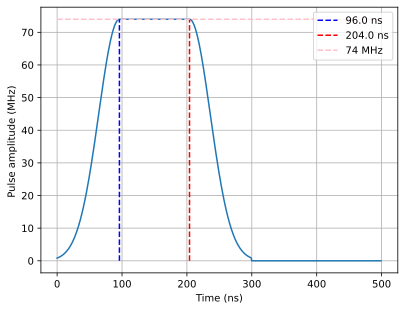

In [ ]:
t= np.arange(0,500)
ts = np.linspace(0, 500, 6)
y , rt, ft = modulation(t, pulse)

y = ((y * 2)/ (np.pi * 2))*(1e3) 
plt.plot(t, y)
#plt.vlines((16),y[len(y)], )
plt.vlines(rt, 0, y[100], linestyles="--", label = f"{rt} ns", colors="b")
plt.vlines(ft, 0, y[100], linestyles="--", label = f"{ft} ns", colors="r")
plt.hlines(y[100], 0, 500, linestyles="--", label = "74 MHz", colors="pink")
plt.xticks(ts)
plt.xlabel("Time (ns)")
plt.ylabel("Pulse amplitude (MHz) ")
plt.legend()
plt.grid()
plt.show()